# GATE: Voronoi 10% run

Quick analysis of the 50-epoch GATE run using all node features and the Voronoi contact-area edge feature. The notebook reads the copied run artifacts directly and does not modify them.

In [1]:
from pathlib import Path
import json
import shutil

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use LaTeX's Computer Modern when LaTeX is installed; retain the matching
# Computer Modern math font as a portable fallback.
mpl.rcParams.update({
    "text.usetex": shutil.which("latex") is not None,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.frameon": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

candidates = [
    Path.cwd() / "voronoi_10pct_50epochs",  # notebook launched from gate_run/
    Path.cwd() / "gate_run" / "voronoi_10pct_50epochs",  # launched from repo root
    Path.cwd(),  # notebook launched from the run directory
]
RUN_DIR = next((path.resolve() for path in candidates if (path / "loss_history.csv").is_file()), None)
if RUN_DIR is None:
    raise FileNotFoundError("Could not locate voronoi_10pct_50epochs/loss_history.csv")
FIGURE_DIR = RUN_DIR / "analysis_figures"
FIGURE_DIR.mkdir(exist_ok=True)
print(f"Run directory: {RUN_DIR}")
print(f"LaTeX rendering: {mpl.rcParams['text.usetex']}")

Run directory: /scratch/PPI-graph_autoencoder/gate_run/voronoi_10pct_50epochs
LaTeX rendering: True


In [2]:
history = pd.read_csv(RUN_DIR / "loss_history.csv")
predictions = pd.read_csv(RUN_DIR / "test_predictions.csv")
splits = json.loads((RUN_DIR / "target_splits.json").read_text())

optional_csvs = {
    name: pd.read_csv(RUN_DIR / name)
    for name in ("reconstruction_summary.csv", "reconstruction_by_target.csv")
    if (RUN_DIR / name).is_file()
}

y_true = predictions["true_target"].to_numpy(float)
y_pred = predictions["predicted_target"].to_numpy(float)
residual = y_pred - y_true
rmse = np.sqrt(np.mean(residual**2))
mae = np.mean(np.abs(residual))
r2 = 1 - np.sum(residual**2) / np.sum((y_true - y_true.mean())**2)
pearson = np.corrcoef(y_true, y_pred)[0, 1]
spearman = pd.Series(y_true).corr(pd.Series(y_pred), method="spearman")
best_row = history.loc[history["val_loss"].idxmin()]

overview = pd.Series({
    "epochs completed": len(history),
    "best epoch (validation loss)": int(best_row["epoch"]),
    "best validation loss": best_row["val_loss"],
    "test predictions": len(predictions),
    "test targets": predictions["target_id"].nunique(),
    "RMSE": rmse,
    "MAE": mae,
    "R-squared": r2,
    "Pearson r": pearson,
    "Spearman rho": spearman,
}, name="value")
display(overview.to_frame())
display(pd.DataFrame({
    split: {"targets": info["target_count"], "models": info["sample_count"]}
    for split, info in splits["splits"].items()
}).T)
if not optional_csvs:
    print("Note: reconstruction CSVs are not present in this copied run; reconstruction plots are skipped.")

,value
epochs completed,50.000000
best epoch (validation loss),50.000000
best validation loss,32.165065
test predictions,3044.000000
test targets,25.000000
RMSE,0.283897
MAE,0.248097
R-squared,0.165078
Pearson r,0.422840
Spearman rho,0.399333


,targets,models
train,90,10910
val,10,1132
test,25,3044


Note: reconstruction CSVs are not present in this copied run; reconstruction plots are skipped.


## Observed versus predicted DockQ for individual targets

All panels use identical axes. Each title reports that target's sample count and Spearman rank correlation.

In [ ]:
target_names = sorted(predictions["target_id"].unique())
ncols = 5
nrows = int(np.ceil(len(target_names) / ncols))
shared_min = min(y_true.min(), y_pred.min())
shared_max = max(y_true.max(), y_pred.max())
shared_pad = 0.03 * (shared_max - shared_min)
shared_limits = (shared_min - shared_pad, shared_max + shared_pad)

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 2.55 * nrows), sharex=True, sharey=True, constrained_layout=True)
flat_axes = np.atleast_1d(axes).flat
for ax, target_id in zip(flat_axes, target_names):
    target_data = predictions.loc[predictions["target_id"] == target_id]
    target_spearman = target_data["true_target"].corr(target_data["predicted_target"], method="spearman")
    ax.scatter(target_data["true_target"], target_data["predicted_target"], s=13, alpha=0.55, color="#2166ac", edgecolors="none")
    ax.plot(shared_limits, shared_limits, color="#b2182b", ls="--", lw=0.9)
    ax.set(xlim=shared_limits, ylim=shared_limits, title=rf"{target_id}  ($N={len(target_data)}$, $\rho_s={target_spearman:.2f}$)")
for ax in list(np.atleast_1d(axes).flat)[len(target_names):]:
    ax.set_visible(False)
fig.supxlabel("Observed DockQ")
fig.supylabel("Predicted DockQ")
fig.suptitle("Held-out predictions by target", fontsize=15)
fig.savefig(FIGURE_DIR / "dockq_by_target.pdf")
plt.show()

print(f"Overall test-set Spearman correlation: {spearman:.4f}")

## Training convergence

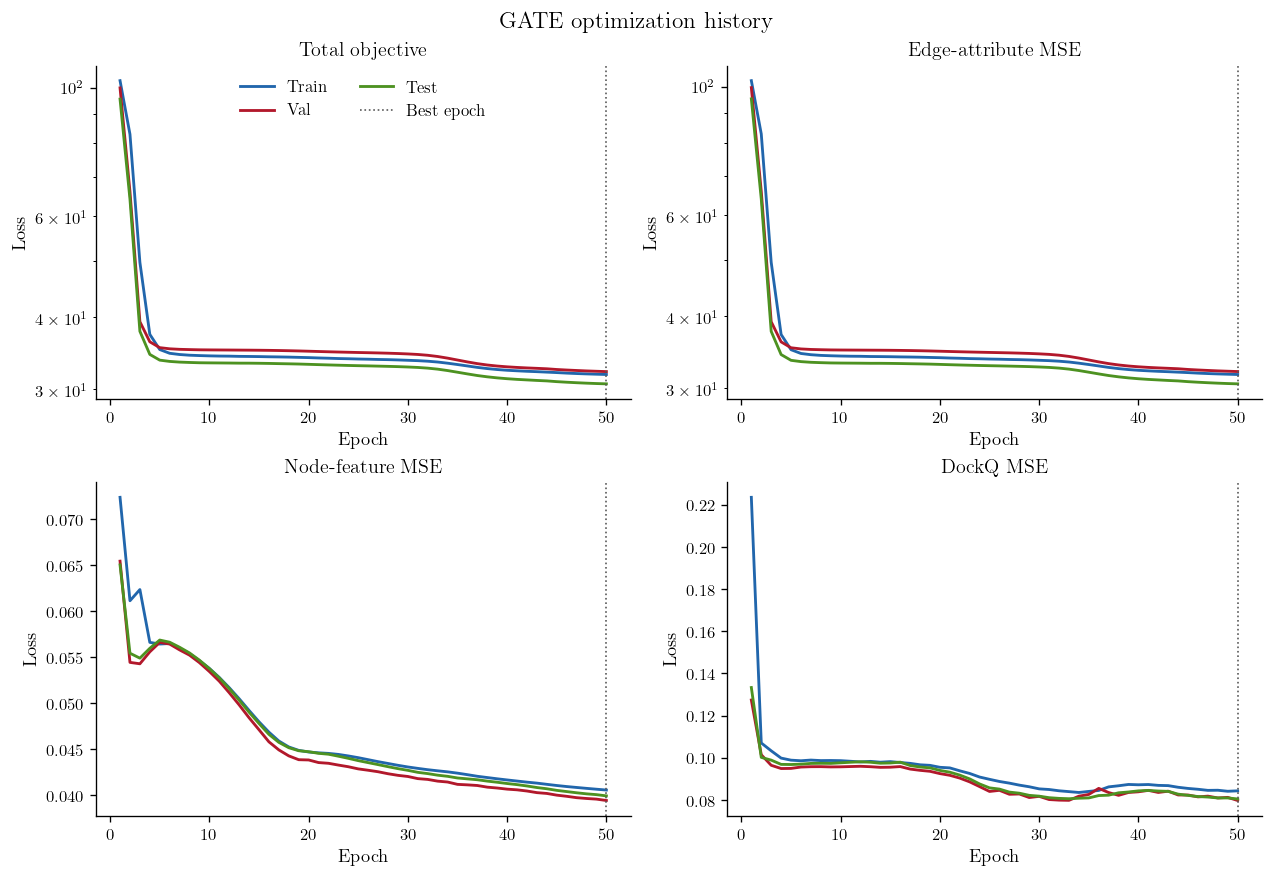

In [3]:
colors = {"train": "#2166ac", "val": "#b2182b", "test": "#4d9221"}
fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.2), constrained_layout=True)
components = [
    ("loss", "Total objective", True),
    ("edge_attr_mse", "Edge-attribute MSE", True),
    ("node_mse", "Node-feature MSE", False),
    ("target_mse", "DockQ MSE", False),
]
for ax, (metric, title, log_scale) in zip(axes.flat, components):
    for split in ("train", "val", "test"):
        ax.plot(history["epoch"], history[f"{split}_{metric}"], color=colors[split], label=split.capitalize(), lw=1.7)
    ax.axvline(best_row["epoch"], color="0.35", ls=":", lw=1, label="Best epoch" if metric == "loss" else None)
    if log_scale:
        ax.set_yscale("log")
    ax.set(title=title, xlabel="Epoch", ylabel="Loss")
axes[0, 0].legend(ncol=2)
fig.suptitle("GATE optimization history", fontsize=14)
fig.savefig(FIGURE_DIR / "training_curves.pdf")
plt.show()

## DockQ prediction quality

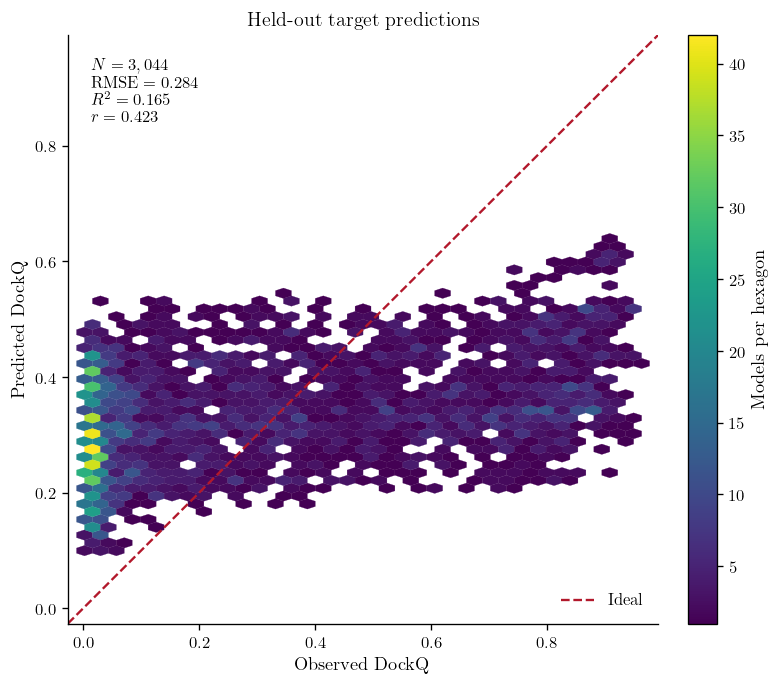

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 5.6), constrained_layout=True)
density = ax.hexbin(y_true, y_pred, gridsize=35, mincnt=1, cmap="viridis", linewidths=0.15)
limits = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
padding = 0.03 * (limits[1] - limits[0])
limits = [limits[0] - padding, limits[1] + padding]
ax.plot(limits, limits, color="#b2182b", ls="--", lw=1.4, label="Ideal")
ax.set(xlim=limits, ylim=limits, xlabel="Observed DockQ", ylabel="Predicted DockQ", title="Held-out target predictions")
metric_text = "\n".join([rf"$N={len(y_true):,}$", rf"$\mathrm{{RMSE}}={rmse:.3f}$", rf"$R^2={r2:.3f}$", rf"$r={pearson:.3f}$", rf"$\rho_s={spearman:.3f}$"])
ax.text(0.04, 0.96, metric_text,
        transform=ax.transAxes, va="top", ha="left")
ax.legend(loc="lower right")
fig.colorbar(density, ax=ax, label="Models per hexagon")
fig.savefig(FIGURE_DIR / "dockq_observed_vs_predicted.pdf")
plt.show()

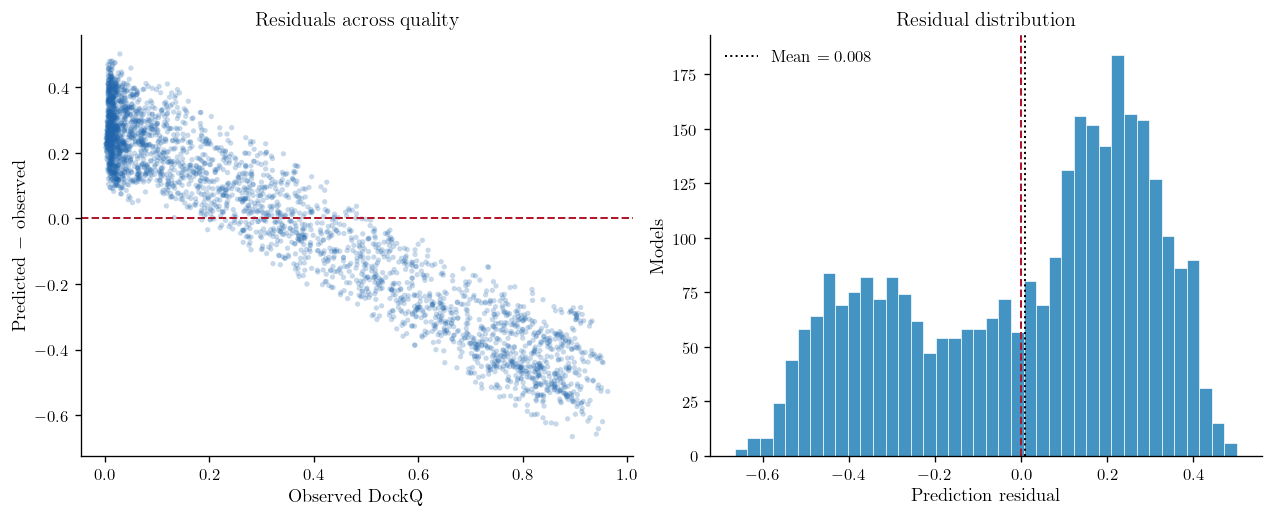

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)
axes[0].scatter(y_true, residual, s=10, alpha=0.25, color="#2166ac", edgecolors="none")
axes[0].axhline(0, color="#b2182b", ls="--", lw=1.2)
axes[0].set(xlabel="Observed DockQ", ylabel="Predicted $-$ observed", title="Residuals across quality")
axes[1].hist(residual, bins=40, color="#4393c3", edgecolor="white", linewidth=0.4)
axes[1].axvline(0, color="#b2182b", ls="--", lw=1.2)
axes[1].axvline(residual.mean(), color="black", ls=":", lw=1.2, label=rf"Mean $={residual.mean():.3f}$")
axes[1].set(xlabel="Prediction residual", ylabel="Models", title="Residual distribution")
axes[1].legend()
fig.savefig(FIGURE_DIR / "dockq_residuals.pdf")
plt.show()

## Calibration by observed DockQ

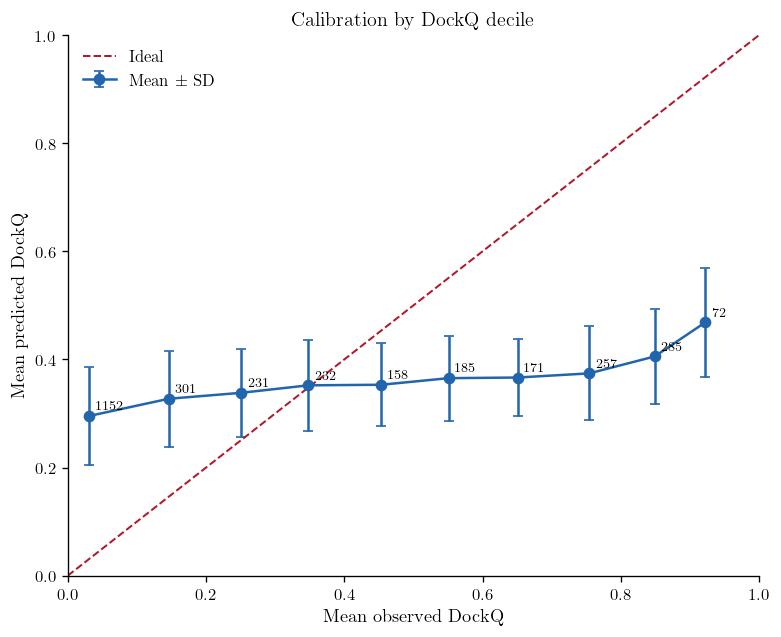

,observed,predicted,predicted_sd,count
dockq_bin,,,,
"(-0.001, 0.1]",0.031161,0.295377,0.090129,1152
"(0.1, 0.2]",0.146030,0.327105,0.088707,301
"(0.2, 0.3]",0.250394,0.338095,0.080788,231
"(0.3, 0.4]",0.347707,0.351913,0.084716,232
"(0.4, 0.5]",0.453601,0.353047,0.077004,158
"(0.5, 0.6]",0.550503,0.365201,0.078771,185
"(0.6, 0.7]",0.650374,0.366359,0.071861,171
"(0.7, 0.8]",0.754000,0.374060,0.086920,257
"(0.8, 0.9]",0.848491,0.405296,0.087809,285


In [6]:
calibration = predictions.assign(
    dockq_bin=pd.cut(predictions["true_target"], bins=np.linspace(0, 1, 11), include_lowest=True),
    residual=residual,
).groupby("dockq_bin", observed=False).agg(
    observed=("true_target", "mean"),
    predicted=("predicted_target", "mean"),
    predicted_sd=("predicted_target", "std"),
    count=("true_target", "size"),
).dropna(subset=["observed"])

fig, ax = plt.subplots(figsize=(6.4, 5.2), constrained_layout=True)
ax.errorbar(calibration["observed"], calibration["predicted"], yerr=calibration["predicted_sd"],
            fmt="o-", color="#2166ac", capsize=3, lw=1.5, label=r"Mean $\pm$ SD")
ax.plot([0, 1], [0, 1], color="#b2182b", ls="--", lw=1.2, label="Ideal")
for _, point in calibration.iterrows():
    ax.annotate(f"{int(point['count'])}", (point["observed"], point["predicted"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean observed DockQ", ylabel="Mean predicted DockQ", title="Calibration by DockQ decile")
ax.legend()
fig.savefig(FIGURE_DIR / "dockq_calibration.pdf")
plt.show()
display(calibration)

## Performance by held-out target

,models,RMSE,MAE,bias,Pearson r
target_id,,,,,
5maw,130,0.190,0.158,-0.008,0.933
1r8o,131,0.197,0.178,-0.015,0.962
4qjf,111,0.212,0.187,-0.022,0.925
3fpn,134,0.238,0.203,-0.039,0.748
5mu7,114,0.247,0.224,0.048,0.847
2fju,90,0.248,0.211,-0.034,0.266
2ayo,87,0.250,0.212,-0.044,0.795
2fhz,122,0.253,0.216,-0.032,0.927
4u1c,93,0.266,0.226,-0.049,0.460


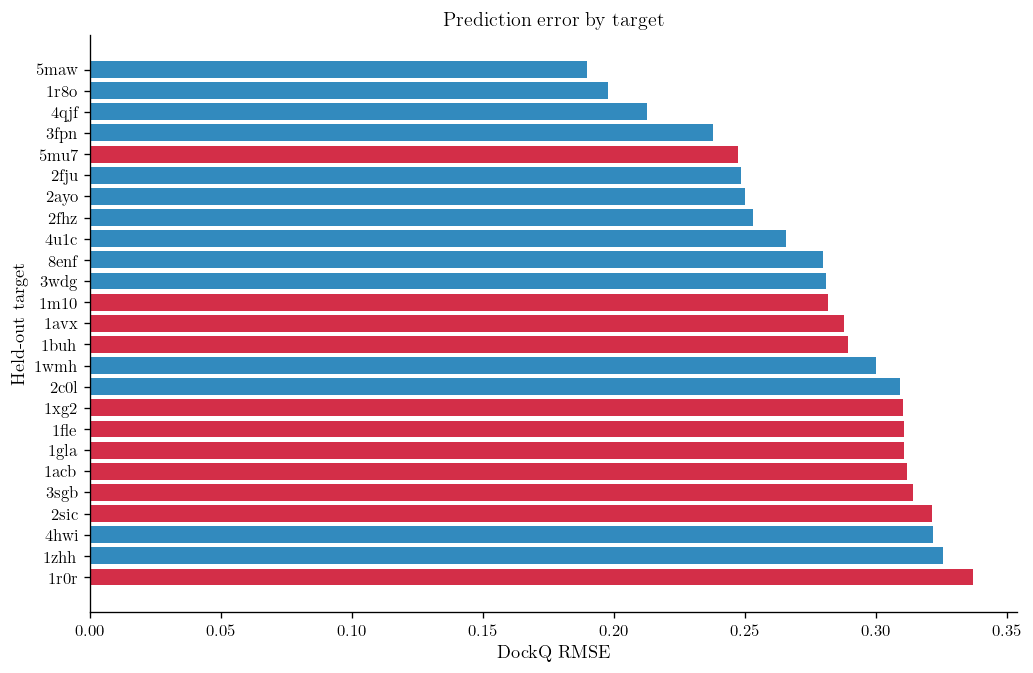

In [7]:
def target_metrics(group):
    error = group["predicted_target"].to_numpy() - group["true_target"].to_numpy()
    pearson_r = group["true_target"].corr(group["predicted_target"]) if len(group) > 1 else np.nan
    spearman_rho = group["true_target"].corr(group["predicted_target"], method="spearman") if len(group) > 1 else np.nan
    return pd.Series({"models": len(group), "RMSE": np.sqrt(np.mean(error**2)), "MAE": np.mean(np.abs(error)), "bias": np.mean(error), "Pearson r": pearson_r, "Spearman rho": spearman_rho})

by_target = predictions.groupby("target_id", sort=True).apply(target_metrics, include_groups=False)
display(by_target.sort_values("RMSE").style.format({"models": "{:.0f}", "RMSE": "{:.3f}", "MAE": "{:.3f}", "bias": "{:.3f}", "Pearson r": "{:.3f}", "Spearman rho": "{:.3f}"}))

ordered = by_target.sort_values("RMSE")
fig, ax = plt.subplots(figsize=(8.5, max(5, 0.22 * len(ordered))), constrained_layout=True)
bar_colors = np.where(ordered["bias"] >= 0, "#ca0020", "#0571b0")
ax.barh(ordered.index, ordered["RMSE"], color=bar_colors, alpha=0.82)
ax.set(xlabel="DockQ RMSE", ylabel="Held-out target", title="Prediction error by target")
ax.invert_yaxis()
fig.savefig(FIGURE_DIR / "target_rmse.pdf")
plt.show()

## Notes

- Positive residuals indicate DockQ overprediction.
- The number beside each calibration point is its model count.
- PDF figures are saved in `voronoi_10pct_50epochs/analysis_figures/`.
- The test split is target-wise, so the per-target panel is especially useful for detecting generalization failures hidden by global averages.